In [2]:
import os
import gzip
import json
import pandas as pd
from typing import Optional, List, Callable, Dict, Any, Iterable, Union

def _open_text(path: str):
    """Open normal text file or .gz file as a text stream."""
    return gzip.open(path, "rt", encoding="utf-8") if path.endswith(".gz") else open(path, "r", encoding="utf-8")

def iter_jsonl_chunks(
    path: str,
    chunksize: int = 100_000,
    columns: Optional[List[str]] = None,
    row_filter: Optional[Callable[[Dict[str, Any]], bool]] = None,
    verbose: bool = True,
) -> Iterable[pd.DataFrame]:
    """
    Stream a JSON Lines file and yield DataFrame chunks.
    - columns: keep only required keys (saves RAM)
    - row_filter: filter rows while reading (saves RAM + time)
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")

    buf = []
    total = 0

    with _open_text(path) as f:
        for i, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue

            obj = json.loads(line)

            if row_filter and not row_filter(obj):
                continue

            if columns is not None:
                obj = {k: obj.get(k, None) for k in columns}

            buf.append(obj)

            if len(buf) >= chunksize:
                df = pd.DataFrame(buf)
                total += len(df)
                if verbose:
                    print(f"\u2705 yielded {len(df):,} rows | total read {total:,}")
                yield df
                buf = []

    if buf:
        df = pd.DataFrame(buf)
        total += len(df)
        if verbose:
            print(f"\u2705 yielded FINAL {len(df):,} rows | total read {total:,}")
        yield df


In [6]:
def load_and_peek(
    path: str,
    chunksize: int = 100_000,
    columns: Optional[List[str]] = None,
    row_filter: Optional[Callable[[Dict[str, Any]], bool]] = None,
    peek_rows: int = 5_000,
    full_load: bool = False,
):
    chunk_iter = iter_jsonl_chunks(
        path=path,
        chunksize=chunksize,
        columns=columns,
        row_filter=row_filter,
        verbose=True
    )

    # Preview safely
    preview_parts = []
    remaining = peek_rows

    for chunk in chunk_iter:
        take = min(remaining, len(chunk))
        preview_parts.append(chunk.head(take))
        remaining -= take
        if remaining <= 0:
            break

    # Full load (RAM heavy)
    print("\n\u26a0\ufe0f Full loading entire file into memory...")
    full_df = pd.concat(
        iter_jsonl_chunks(path, chunksize=chunksize, columns=columns, row_filter=row_filter, verbose=True),
        ignore_index=True
    )

    print("\n===== FULL DATA LOADED =====")
    print("Shape:", full_df.shape)
    display(full_df.head(10))
    return full_df


In [7]:
business_preview = load_and_peek(
    "./yelp_dataset/filtered_food_data.json",
    chunksize=50_000,
    peek_rows=5000,
    full_load=True
)


✅ yielded 50,000 rows | total read 50,000

⚠️ Full loading entire file into memory...
✅ yielded 50,000 rows | total read 50,000
✅ yielded FINAL 16,770 rows | total read 66,770

===== FULL DATA LOADED =====
Shape: (66770, 9)


,business_id,city,state,postal_code,latitude,longitude,categories,category_list,filtered_categories
0,MTSW4McQd7CbVtyjqoe9mw,Philadelphia,PA,19107,39.955505,-75.155564,"Restaurants, Food, Bubble Tea, Coffee & Tea, B...","[Restaurants, Food, Bubble Tea, Coffee & Tea, ...","[Restaurants, Food, Bubble Tea, Coffee & Tea, ..."
1,mWMc6_wTdE0EUBKIGXDVfA,Green Lane,PA,18054,40.338183,-75.471659,"Brewpubs, Breweries, Food","[Brewpubs, Breweries, Food]","[Brewpubs, Breweries, Food]"
2,CF33F8-E6oudUQ46HnavjQ,Ashland City,TN,37015,36.269593,-87.058943,"Burgers, Fast Food, Sandwiches, Food, Ice Crea...","[Burgers, Fast Food, Sandwiches, Food, Ice Cre...","[Burgers, Fast Food, Sandwiches, Food, Ice Cre..."
3,k0hlBqXX-Bt0vf1op7Jr1w,Affton,MO,63123,38.565165,-90.321087,"Pubs, Restaurants, Italian, Bars, American (Tr...","[Pubs, Restaurants, Italian, Bars, American (T...","[Pubs, Restaurants, Italian, Bars, American (T..."
4,bBDDEgkFA1Otx9Lfe7BZUQ,Nashville,TN,37207,36.208102,-86.768170,"Ice Cream & Frozen Yogurt, Fast Food, Burgers,...","[Ice Cream & Frozen Yogurt, Fast Food, Burgers...","[Ice Cream & Frozen Yogurt, Fast Food, Burgers..."
5,eEOYSgkmpB90uNA7lDOMRA,Tampa Bay,FL,33602,27.955269,-82.456320,"Vietnamese, Food, Restaurants, Food Trucks","[Vietnamese, Food, Restaurants, Food Trucks]","[Vietnamese, Food, Restaurants]"
6,il_Ro8jwPlHresjw9EGmBg,Indianapolis,IN,46227,39.637133,-86.127217,"American (Traditional), Restaurants, Diners, B...","[American (Traditional), Restaurants, Diners, ...","[American (Traditional), Restaurants, Breakfas..."
7,0bPLkL0QhhPO5kt1_EXmNQ,Largo,FL,33771,27.916116,-82.760461,"Food, Delis, Italian, Bakeries, Restaurants","[Food, Delis, Italian, Bakeries, Restaurants]","[Food, Italian, Bakeries, Restaurants]"
8,MUTTqe8uqyMdBl186RmNeA,Philadelphia,PA,19106,39.953949,-75.143226,"Sushi Bars, Restaurants, Japanese","[Sushi Bars, Restaurants, Japanese]","[Sushi Bars, Restaurants]"
9,ROeacJQwBeh05Rqg7F6TCg,Philadelphia,PA,19147,39.943223,-75.162568,"Korean, Restaurants","[Korean, Restaurants]","[Korean, Restaurants]"


In [8]:
# Count businesses per state
state_counts = (
    business_preview
    .groupby("state")
    .size()
    .reset_index(name="business_count")
    .sort_values("business_count", ascending=False)
)
state_counts.head(10)


,state,business_count
16,PA,15826
5,FL,11261
17,TN,5460
11,MO,5283
9,IN,5270
10,LA,4845
14,NJ,4173
1,AZ,3452
0,AB,3056
15,NV,2396


In [9]:
# Top 10 states by number of businesses
top_10_states = (
    state_counts
    .sort_values("business_count", ascending=False)
    .head(10)["state"]
    .tolist()
)
top_10_states


['PA', 'FL', 'TN', 'MO', 'IN', 'LA', 'NJ', 'AZ', 'AB', 'NV']

In [6]:
business_top_states = business_preview[
    business_preview["state"].isin(top_10_states)
]
business_top_states.shape
business_top_states.head()


,business_id,city,state,postal_code,latitude,longitude,categories,category_list,filtered_categories
0,MTSW4McQd7CbVtyjqoe9mw,Philadelphia,PA,19107,39.955505,-75.155564,"Restaurants, Food, Bubble Tea, Coffee & Tea, B...","[Restaurants, Food, Bubble Tea, Coffee & Tea, ...","[Restaurants, Food, Bubble Tea, Coffee & Tea, ..."
1,mWMc6_wTdE0EUBKIGXDVfA,Green Lane,PA,18054,40.338183,-75.471659,"Brewpubs, Breweries, Food","[Brewpubs, Breweries, Food]","[Brewpubs, Breweries, Food]"
2,CF33F8-E6oudUQ46HnavjQ,Ashland City,TN,37015,36.269593,-87.058943,"Burgers, Fast Food, Sandwiches, Food, Ice Crea...","[Burgers, Fast Food, Sandwiches, Food, Ice Cre...","[Burgers, Fast Food, Sandwiches, Food, Ice Cre..."
3,k0hlBqXX-Bt0vf1op7Jr1w,Affton,MO,63123,38.565165,-90.321087,"Pubs, Restaurants, Italian, Bars, American (Tr...","[Pubs, Restaurants, Italian, Bars, American (T...","[Pubs, Restaurants, Italian, Bars, American (T..."
4,bBDDEgkFA1Otx9Lfe7BZUQ,Nashville,TN,37207,36.208102,-86.768170,"Ice Cream & Frozen Yogurt, Fast Food, Burgers,...","[Ice Cream & Frozen Yogurt, Fast Food, Burgers...","[Ice Cream & Frozen Yogurt, Fast Food, Burgers..."


In [10]:
checkin_preview = load_and_peek(
    "./yelp_dataset/yelp_academic_dataset_checkin.json",
    chunksize=50_000,
    peek_rows=5000,
    full_load=True
)


✅ yielded 50,000 rows | total read 50,000

⚠️ Full loading entire file into memory...
✅ yielded 50,000 rows | total read 50,000
✅ yielded 50,000 rows | total read 100,000
✅ yielded FINAL 31,930 rows | total read 131,930

===== FULL DATA LOADED =====
Shape: (131930, 2)


,business_id,date
0,---kPU91CF4Lq2-WlRu9Lw,"2020-03-13 21:10:56, 2020-06-02 22:18:06, 2020..."
1,--0iUa4sNDFiZFrAdIWhZQ,"2010-09-13 21:43:09, 2011-05-04 23:08:15, 2011..."
2,--30_8IhuyMHbSOcNWd6DQ,"2013-06-14 23:29:17, 2014-08-13 23:20:22"
3,--7PUidqRWpRSpXebiyxTg,"2011-02-15 17:12:00, 2011-07-28 02:46:10, 2012..."
4,--7jw19RH9JKXgFohspgQw,"2014-04-21 20:42:11, 2014-04-28 21:04:46, 2014..."
5,--8IbOsAAxjKRoYsBFL-PA,"2015-06-06 01:03:19, 2015-07-29 16:50:58, 2015..."
6,--9osgUCSDUWUkoTLdvYhQ,"2015-06-13 02:00:57, 2015-07-04 00:44:09, 2015..."
7,--ARBQr1WMsTWiwOKOj-FQ,"2014-12-12 00:44:23, 2015-01-09 00:19:52, 2015..."
8,--FWWsIwxRwuw9vIMImcQg,"2010-09-11 16:28:39, 2010-12-22 21:14:19, 2011..."
9,--FcbSxK1AoEtEAxOgBaCw,"2017-08-18 19:43:50, 2017-10-07 22:38:38, 2017..."


In [11]:
# same for review dataset if needed
review_preview = load_and_peek(
    "./yelp_dataset/yelp_academic_dataset_review.json", 
    chunksize=50_000,
    peek_rows=5000,
    full_load=True
)

✅ yielded 50,000 rows | total read 50,000

⚠️ Full loading entire file into memory...
✅ yielded 50,000 rows | total read 50,000
✅ yielded 50,000 rows | total read 100,000
✅ yielded 50,000 rows | total read 150,000
✅ yielded 50,000 rows | total read 200,000
✅ yielded 50,000 rows | total read 250,000
✅ yielded 50,000 rows | total read 300,000
✅ yielded 50,000 rows | total read 350,000
✅ yielded 50,000 rows | total read 400,000
✅ yielded 50,000 rows | total read 450,000
✅ yielded 50,000 rows | total read 500,000
✅ yielded 50,000 rows | total read 550,000
✅ yielded 50,000 rows | total read 600,000
✅ yielded 50,000 rows | total read 650,000
✅ yielded 50,000 rows | total read 700,000
✅ yielded 50,000 rows | total read 750,000
✅ yielded 50,000 rows | total read 800,000
✅ yielded 50,000 rows | total read 850,000
✅ yielded 50,000 rows | total read 900,000
✅ yielded 50,000 rows | total read 950,000
✅ yielded 50,000 rows | total read 1,000,000
✅ yielded 50,000 rows | total read 1,050,000
✅ yielde

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15
5,JrIxlS1TzJ-iCu79ul40cQ,eUta8W_HdHMXPzLBBZhL1A,04UD14gamNjLY0IDYVhHJg,1.0,1,2,1,I am a long term frequent customer of this est...,2015-09-23 23:10:31
6,6AxgBCNX_PNTOxmbRSwcKQ,r3zeYsv1XFBRA4dJpL78cw,gmjsEdUsKpj9Xxu6pdjH0g,5.0,0,2,0,Loved this tour! I grabbed a groupon and the p...,2015-01-03 23:21:18
7,_ZeMknuYdlQcUqng_Im3yg,yfFzsLmaWF2d4Sr0UNbBgg,LHSTtnW3YHCeUkRDGyJOyw,5.0,2,0,0,Amazingly amazing wings and homemade bleu chee...,2015-08-07 02:29:16
8,ZKvDG2sBvHVdF5oBNUOpAQ,wSTuiTk-sKNdcFyprzZAjg,B5XSoSG3SfvQGtKEGQ1tSQ,3.0,1,1,0,This easter instead of going to Lopez Lake we ...,2016-03-30 22:46:33
9,pUycOfUwM8vqX7KjRRhUEA,59MxRhNVhU9MYndMkz0wtw,gebiRewfieSdtt17PTW6Zg,3.0,0,0,0,Had a party of 6 here for hibachi. Our waitres...,2016-07-25 07:31:06


In [12]:
DIETARY_GROUPS = {
    # Sugar / dessert seeking
    "High_Sugar_Dessert": {
        "Ice Cream", "Frozen Yogurt", "Ice Cream & Frozen Yogurt",
        "Desserts", "Cupcakes", "Bakery", "Bakeries"
    },

    # Energy-dense / fast food seeking
    "Energy_Dense_Food": {
        "Fast Food", "Burger", "Burgers", "Pizza", "Sandwich", "Sandwiches",
        "BBQ", "Buffet", "Food Trucks", "Delis"
    },

    # Hot comfort food (weather-sensitive)
    "Hot_Comfort_Food": {
        "Soup", "Noodles", "Ramen", "Hot Pot", "Curry"
    },

    # Caffeinated / beverage seeking (often sugar too, but keep separate for interpretability)
    "Caffeinated_Beverage": {
        "Coffee", "Tea", "Coffee & Tea", "Cafes", "Cafe"
    },

    # Sweet / non-caffeinated beverages
    "Sweet_Beverage": {
        "Bubble Tea", "Juice", "Smoothie", "Juice Bars", "Juice Bars & Smoothies"
    },

    # Alcohol-related consumption proxy
    "Alcohol_Consumption": {
        "Bar", "Bars", "Pub", "Pubs", "Brewery", "Brewpub", "Wine", "Wine Bars"
    },

    # Health-oriented choices
    "Healthy_Light_Meal": {
        "Vegan", "Vegetarian", "Health Food", "Organic", "Salad"
    },

    # Meal timing / breakfast pattern
    "Breakfast_Brunch": {
        "Breakfast", "Brunch", "Breakfast & Brunch"
    },
    
    "Full_Service_Meal":{

    # Asian cuisines
    "Chinese", "Chinese Food", "Thai", "Japanese", "Korean",
    "Vietnamese", "Indian", "Malaysian", "Asian Fusion",

    # European / Western cuisines
    "Italian", "French", "Greek", "Mediterranean",
    "American", "American (Traditional)", "American (New)",
    "Canadian",

    # Other cuisines
    "Mexican", "Latin American", "Middle Eastern",
    "Turkish", "Caribbean", "African",

    # Protein-focused sit-down meals
    "Seafood", "Steakhouse", "Steakhouses"
    }

}


In [14]:
GENERAL_TERMS = {"Food", "Restaurant", "Restaurants", "Food Court", "Bistro", "Bistros"}

In [15]:
DIETARY_PRIORITY = [
    "Alcohol_Consumption",
    "High_Sugar_Dessert",
    "Sweet_Beverage",
    "Caffeinated_Beverage",
    "Energy_Dense_Food",
    "Hot_Comfort_Food",
    "Healthy_Light_Meal",
    "Breakfast_Brunch",
    "Full_Service_Meal",
]


In [18]:
def map_to_dietary_behavior(filtered_categories):
    """
    filtered_categories: list of strings
    returns: one dietary_behavior_type label (string) or 'Other'
    """
    if not isinstance(filtered_categories, list) or len(filtered_categories) == 0:
        return "Other"

    cats = {c.strip() for c in filtered_categories if isinstance(c, str) and c.strip()}
    cats = cats - GENERAL_TERMS  # remove noisy general terms

    for group in DIETARY_PRIORITY:
        if len(cats.intersection(DIETARY_GROUPS[group])) > 0:
            return group

    return "Other"


In [20]:
business_top_states = business_preview[
    business_preview["state"].isin(top_10_states)
]

business_top_states.shape
business_top_states.head()

,business_id,city,state,postal_code,latitude,longitude,categories,category_list,filtered_categories
0,MTSW4McQd7CbVtyjqoe9mw,Philadelphia,PA,19107,39.955505,-75.155564,"Restaurants, Food, Bubble Tea, Coffee & Tea, B...","[Restaurants, Food, Bubble Tea, Coffee & Tea, ...","[Restaurants, Food, Bubble Tea, Coffee & Tea, ..."
1,mWMc6_wTdE0EUBKIGXDVfA,Green Lane,PA,18054,40.338183,-75.471659,"Brewpubs, Breweries, Food","[Brewpubs, Breweries, Food]","[Brewpubs, Breweries, Food]"
2,CF33F8-E6oudUQ46HnavjQ,Ashland City,TN,37015,36.269593,-87.058943,"Burgers, Fast Food, Sandwiches, Food, Ice Crea...","[Burgers, Fast Food, Sandwiches, Food, Ice Cre...","[Burgers, Fast Food, Sandwiches, Food, Ice Cre..."
3,k0hlBqXX-Bt0vf1op7Jr1w,Affton,MO,63123,38.565165,-90.321087,"Pubs, Restaurants, Italian, Bars, American (Tr...","[Pubs, Restaurants, Italian, Bars, American (T...","[Pubs, Restaurants, Italian, Bars, American (T..."
4,bBDDEgkFA1Otx9Lfe7BZUQ,Nashville,TN,37207,36.208102,-86.768170,"Ice Cream & Frozen Yogurt, Fast Food, Burgers,...","[Ice Cream & Frozen Yogurt, Fast Food, Burgers...","[Ice Cream & Frozen Yogurt, Fast Food, Burgers..."


In [21]:
# Creates a new ML-ready target label
business_top_states = business_top_states.copy()
business_top_states["dietary_behavior_type"] = business_top_states["filtered_categories"].apply(map_to_dietary_behavior)

# See distribution
business_top_states["dietary_behavior_type"].value_counts(dropna=False)


dietary_behavior_type
Energy_Dense_Food       13514
Full_Service_Meal       11996
Other                   10421
Alcohol_Consumption     10151
High_Sugar_Dessert       6372
Caffeinated_Beverage     5671
Breakfast_Brunch         1445
Healthy_Light_Meal       1142
Sweet_Beverage            310
Name: count, dtype: int64

In [22]:
business_top_states[["state", "filtered_categories", "dietary_behavior_type"]].head(20)

,state,filtered_categories,dietary_behavior_type
0,PA,"[Restaurants, Food, Bubble Tea, Coffee & Tea, ...",High_Sugar_Dessert
1,PA,"[Brewpubs, Breweries, Food]",Other
2,TN,"[Burgers, Fast Food, Sandwiches, Food, Ice Cre...",High_Sugar_Dessert
3,MO,"[Pubs, Restaurants, Italian, Bars, American (T...",Alcohol_Consumption
4,TN,"[Ice Cream & Frozen Yogurt, Fast Food, Burgers...",High_Sugar_Dessert
5,FL,"[Vietnamese, Food, Restaurants]",Full_Service_Meal
6,IN,"[American (Traditional), Restaurants, Breakfas...",Breakfast_Brunch
7,FL,"[Food, Italian, Bakeries, Restaurants]",High_Sugar_Dessert
8,PA,"[Sushi Bars, Restaurants]",Other
9,PA,"[Korean, Restaurants]",Full_Service_Meal


In [23]:
other_rate = (business_top_states["dietary_behavior_type"] == "Other").mean()
print(f"Other rate: {other_rate:.2%}")


Other rate: 17.08%


---
## Step 2 — Explode Check-in Timestamps
Each business has a comma-separated list of all visit timestamps. We explode them into one row per visit.

In [24]:
from datetime import datetime


def explode_checkins_chunked(df: pd.DataFrame, chunksize: int = 10_000) -> pd.DataFrame:
    """
    Explode comma-separated timestamp strings into one row per check-in.
    Processes in chunks to avoid RAM spikes on large datasets.
 
    Returns: business_id | checkin_dt | year | month | day | hour | day_of_week | is_weekend
    """
    all_chunks = []
    total_rows = len(df)
 
    for start in range(0, total_rows, chunksize):
        chunk = df.iloc[start : start + chunksize].copy()
 
        # Explode: split the comma-separated date string into multiple rows
        chunk["date"] = chunk["date"].fillna("").astype(str)
        chunk["date"] = chunk["date"].str.split(",")
        chunk = chunk.explode("date")
        chunk["date"] = chunk["date"].str.strip()
        chunk = chunk[chunk["date"] != ""]  # drop blanks
 
        # Parse timestamps
        chunk["checkin_dt"] = pd.to_datetime(chunk["date"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
        chunk = chunk.dropna(subset=["checkin_dt"])
 
        # Extract time features
        chunk["year"]        = chunk["checkin_dt"].dt.year
        chunk["month"]       = chunk["checkin_dt"].dt.month
        chunk["day"]         = chunk["checkin_dt"].dt.day
        chunk["hour"]        = chunk["checkin_dt"].dt.hour
        chunk["day_of_week"] = chunk["checkin_dt"].dt.dayofweek   # 0=Mon, 6=Sun
        chunk["is_weekend"]  = (chunk["checkin_dt"].dt.dayofweek >= 5).astype(int)
 
        chunk = chunk[["business_id", "checkin_dt", "year", "month", "day",
                        "hour", "day_of_week", "is_weekend"]].reset_index(drop=True)
 
        all_chunks.append(chunk)
        processed = min(start + chunksize, total_rows)
        print(f"  ✅ processed {processed:,} / {total_rows:,} businesses "
              f"→ {sum(len(c) for c in all_chunks):,} check-ins so far")
 
    checkin_long = pd.concat(all_chunks, ignore_index=True)
    print(f"\nDone. Total check-ins: {len(checkin_long):,}")
    return checkin_long
 
 
# ── Usage ────────────────────────────────────────────────────────────────────
checkin_long = explode_checkins_chunked(checkin_preview, chunksize=10_000)
checkin_long.head()

  ✅ processed 10,000 / 131,930 businesses → 1,053,026 check-ins so far
  ✅ processed 20,000 / 131,930 businesses → 2,127,565 check-ins so far
  ✅ processed 30,000 / 131,930 businesses → 3,122,403 check-ins so far
  ✅ processed 40,000 / 131,930 businesses → 4,207,703 check-ins so far
  ✅ processed 50,000 / 131,930 businesses → 5,213,344 check-ins so far
  ✅ processed 60,000 / 131,930 businesses → 6,231,978 check-ins so far
  ✅ processed 70,000 / 131,930 businesses → 7,235,042 check-ins so far
  ✅ processed 80,000 / 131,930 businesses → 8,228,611 check-ins so far
  ✅ processed 90,000 / 131,930 businesses → 9,232,674 check-ins so far
  ✅ processed 100,000 / 131,930 businesses → 10,244,361 check-ins so far
  ✅ processed 110,000 / 131,930 businesses → 11,241,205 check-ins so far
  ✅ processed 120,000 / 131,930 businesses → 12,222,739 check-ins so far
  ✅ processed 130,000 / 131,930 businesses → 13,173,832 check-ins so far
  ✅ processed 131,930 / 131,930 businesses → 13,356,875 check-ins so 

,business_id,checkin_dt,year,month,day,hour,day_of_week,is_weekend
0,---kPU91CF4Lq2-WlRu9Lw,2020-03-13 21:10:56,2020,3,13,21,4,0
1,---kPU91CF4Lq2-WlRu9Lw,2020-06-02 22:18:06,2020,6,2,22,1,0
2,---kPU91CF4Lq2-WlRu9Lw,2020-07-24 22:42:27,2020,7,24,22,4,0
3,---kPU91CF4Lq2-WlRu9Lw,2020-10-24 21:36:13,2020,10,24,21,5,1
4,---kPU91CF4Lq2-WlRu9Lw,2020-12-09 21:23:33,2020,12,9,21,2,0


In [31]:
def month_to_season(m):
    if m in (12, 1, 2):  return "Winter"
    if m in (3, 4, 5):   return "Spring"
    if m in (6, 7, 8):   return "Summer"
    return "Fall"

checkin_long["season"] = checkin_long["month"].apply(month_to_season)
checkin_long[["checkin_dt", "hour", "day_of_week", "is_weekend", "season"]].head()

,checkin_dt,hour,day_of_week,is_weekend,season
0,2020-03-13 21:10:56,21,4,0,Spring
1,2020-06-02 22:18:06,22,1,0,Summer
2,2020-07-24 22:42:27,22,4,0,Summer
3,2020-10-24 21:36:13,21,5,1,Fall
4,2020-12-09 21:23:33,21,2,0,Winter


---
## Step 3 — Fetch Historical Weather
We use [Open-Meteo](https://open-meteo.com/) (free, no API key). One representative city per state.

In [33]:
import requests

# Representative city coordinates for the top Yelp states
STATE_COORDS = {
    "PA": (39.95, -75.16),   # Philadelphia
    "AZ": (33.44, -112.07),  # Phoenix
    "NV": (36.17, -115.14),  # Las Vegas
    "FL": (28.54, -81.38),   # Orlando
    "OH": (41.49, -81.69),   # Cleveland
    "NC": (35.23, -80.84),   # Charlotte
    "AB": (51.04, -114.07),  # Calgary
    "LA": (29.95, -90.07),   # New Orleans
    "MO": (38.63, -90.20),   # St. Louis
    "IL": (41.88, -87.63),   # Chicago
}

def fetch_daily_weather(lat: float, lon: float,
                        start_date: str, end_date: str) -> pd.DataFrame:
    """
    Fetch daily weather from Open-Meteo archive API.
    start_date / end_date format: 'YYYY-MM-DD'
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude":   lat,
        "longitude":  lon,
        "start_date": start_date,
        "end_date":   end_date,
        "daily": ",".join([
            "temperature_2m_max",
            "temperature_2m_min",
            "temperature_2m_mean",
            "precipitation_sum",
            "windspeed_10m_max",
        ]),
        "timezone": "auto",
    }
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()["daily"]
    df = pd.DataFrame(data)
    df.rename(columns={
        "time":                 "date",
        "temperature_2m_max":   "temp_max_c",
        "temperature_2m_min":   "temp_min_c",
        "temperature_2m_mean":  "temp_mean_c",
        "precipitation_sum":    "precip_mm",
        "windspeed_10m_max":    "wind_max_kph",
    }, inplace=True)
    df["date"] = pd.to_datetime(df["date"])
    return df

print("fetch_daily_weather() ready")


fetch_daily_weather() ready


In [34]:
WEATHER_CACHE = "./yelp_dataset/weather_by_state.csv"

if os.path.exists(WEATHER_CACHE):
    weather_all = pd.read_csv(WEATHER_CACHE, parse_dates=["date"])
    print(f"Loaded cached weather: {len(weather_all):,} rows")
else:
    dfs = []
    for state, (lat, lon) in STATE_COORDS.items():
        print(f"Fetching {state}...")
        try:
            df = fetch_daily_weather(lat, lon, "2018-01-01", "2022-12-31")
            df["state"] = state
            dfs.append(df)
        except Exception as e:
            print(f"  WARNING: {state} failed — {e}")
    weather_all = pd.concat(dfs, ignore_index=True)
    weather_all.to_csv(WEATHER_CACHE, index=False)
    print(f"Saved: {len(weather_all):,} rows")

print(weather_all.shape)
weather_all.head()


Loaded cached weather: 18,260 rows
(18260, 7)


,date,temp_max_c,temp_min_c,temp_mean_c,precip_mm,wind_max_kph,state
0,2018-01-01,-6.1,-14.0,-10.3,0.0,20.0,PA
1,2018-01-02,-3.4,-11.2,-8.0,0.0,17.1,PA
2,2018-01-03,0.1,-12.1,-6.3,0.0,12.1,PA
3,2018-01-04,-3.5,-8.8,-4.8,12.2,36.7,PA
4,2018-01-05,-8.6,-13.1,-11.2,0.0,32.2,PA


---
## Step 4 — Join: Check-ins + Business Labels + Weather

In [35]:
import pandas as pd
import gc

# ── Pre-build lookup tables (small, keep in memory) ──────────────────────────
business_labels = business_top_states[
    ["business_id", "state", "dietary_behavior_type"]
].copy()
 
weather_lookup = weather_all[
    ["date", "state", "temp_max_c", "temp_min_c", "temp_mean_c", "precip_mm", "wind_max_kph"]
].copy()
weather_lookup["date"] = pd.to_datetime(weather_lookup["date"])
 
# ── Chunked build ─────────────────────────────────────────────────────────────
CHUNKSIZE = 500_000   # tune down if RAM is tight
master_chunks = []
total_in  = len(checkin_long)
total_out = 0
 
for start in range(0, total_in, CHUNKSIZE):
    chunk = checkin_long.iloc[start : start + CHUNKSIZE].copy()
 
    # 1. Merge business labels
    chunk = chunk.merge(business_labels, on="business_id", how="inner")
    if chunk.empty:
        continue
 
    # 2. Build date column for weather join
    chunk["date"] = pd.to_datetime(
        chunk["year"].astype(str) + "-" +
        chunk["month"].astype(str).str.zfill(2) + "-" +
        chunk["day"].astype(str).str.zfill(2)
    )
 
    # 3. Join weather
    chunk = chunk.merge(weather_lookup, on=["date", "state"], how="left")
 
    # 4. Derived weather features
    chunk["temp_range_c"] = chunk["temp_max_c"] - chunk["temp_min_c"]
    chunk["is_rainy"]     = (chunk["precip_mm"]   > 1.0).astype("int8")
    chunk["is_cold"]      = (chunk["temp_mean_c"]  < 5.0).astype("int8")
    chunk["is_hot"]       = (chunk["temp_mean_c"] > 28.0).astype("int8")
 
    # 5. Drop rows with no weather match
    chunk.dropna(subset=["temp_mean_c"], inplace=True)
 
    total_out += len(chunk)
    master_chunks.append(chunk)
 
    # Free the chunk memory before next iteration
    del chunk
    gc.collect()
 
    processed = min(start + CHUNKSIZE, total_in)
    print(f"  ✅ {processed:,} / {total_in:,} rows processed → {total_out:,} kept so far")
 
# ── Combine & free intermediates ──────────────────────────────────────────────
master = pd.concat(master_chunks, ignore_index=True)
 
del master_chunks, business_labels, weather_lookup
gc.collect()
 
print(f"\nMaster dataset: {master.shape}")
master.head()

  ✅ 500,000 / 13,356,875 rows processed → 61,637 kept so far
  ✅ 1,000,000 / 13,356,875 rows processed → 125,783 kept so far
  ✅ 1,500,000 / 13,356,875 rows processed → 189,123 kept so far
  ✅ 2,000,000 / 13,356,875 rows processed → 254,066 kept so far
  ✅ 2,500,000 / 13,356,875 rows processed → 318,461 kept so far
  ✅ 3,000,000 / 13,356,875 rows processed → 388,169 kept so far
  ✅ 3,500,000 / 13,356,875 rows processed → 452,750 kept so far
  ✅ 4,000,000 / 13,356,875 rows processed → 522,655 kept so far
  ✅ 4,500,000 / 13,356,875 rows processed → 593,271 kept so far
  ✅ 5,000,000 / 13,356,875 rows processed → 658,609 kept so far
  ✅ 5,500,000 / 13,356,875 rows processed → 721,622 kept so far
  ✅ 6,000,000 / 13,356,875 rows processed → 782,887 kept so far
  ✅ 6,500,000 / 13,356,875 rows processed → 858,515 kept so far
  ✅ 7,000,000 / 13,356,875 rows processed → 934,157 kept so far
  ✅ 7,500,000 / 13,356,875 rows processed → 999,385 kept so far
  ✅ 8,000,000 / 13,356,875 rows processed →

,business_id,checkin_dt,year,month,day,hour,day_of_week,is_weekend,season,state,...,date,temp_max_c,temp_min_c,temp_mean_c,precip_mm,wind_max_kph,temp_range_c,is_rainy,is_cold,is_hot
0,---kPU91CF4Lq2-WlRu9Lw,2020-03-13 21:10:56,2020,3,13,21,4,0,Spring,FL,...,2020-03-13,30.0,16.2,23.1,0.0,18.2,13.8,0,0,0
1,---kPU91CF4Lq2-WlRu9Lw,2020-06-02 22:18:06,2020,6,2,22,1,0,Summer,FL,...,2020-06-02,28.0,22.4,24.7,2.7,25.2,5.6,1,0,0
2,---kPU91CF4Lq2-WlRu9Lw,2020-07-24 22:42:27,2020,7,24,22,4,0,Summer,FL,...,2020-07-24,31.8,23.7,27.2,1.8,19.3,8.1,1,0,0
3,---kPU91CF4Lq2-WlRu9Lw,2020-10-24 21:36:13,2020,10,24,21,5,1,Fall,FL,...,2020-10-24,27.5,21.4,24.2,2.7,12.3,6.1,1,0,0
4,---kPU91CF4Lq2-WlRu9Lw,2020-12-09 21:23:33,2020,12,9,21,2,0,Winter,FL,...,2020-12-09,14.4,3.8,9.1,0.0,14.5,10.6,0,0,0


In [36]:
# Aggregate to (business_id × date) — one ML row per business per day
agg = (
    master
    .groupby(["business_id","date","state","dietary_behavior_type"])
    .agg(
        checkin_count  = ("business_id", "count"),
        hour_mean      = ("hour",        "mean"),
        is_weekend     = ("is_weekend",  "max"),
        season         = ("season",      "first"),
        temp_mean_c    = ("temp_mean_c", "first"),
        temp_max_c     = ("temp_max_c",  "first"),
        temp_range_c   = ("temp_range_c","first"),
        precip_mm      = ("precip_mm",   "first"),
        wind_max_kph   = ("wind_max_kph","first"),
        is_rainy       = ("is_rainy",    "first"),
        is_cold        = ("is_cold",     "first"),
        is_hot         = ("is_hot",      "first"),
    )
    .reset_index()
)

agg["month"]       = agg["date"].dt.month
agg["day_of_week"] = agg["date"].dt.dayofweek

print(f"Aggregated rows: {len(agg):,}")
agg["dietary_behavior_type"].value_counts()


Aggregated rows: 1,461,595


dietary_behavior_type
Alcohol_Consumption     403515
Full_Service_Meal       266298
Energy_Dense_Food       206131
Other                   172779
Caffeinated_Beverage    159218
High_Sugar_Dessert      151775
Breakfast_Brunch         51687
Healthy_Light_Meal       34501
Sweet_Beverage           15691
Name: count, dtype: int64

---
## Step 5 — Build Feature Matrix & Encode Target

In [38]:
from sklearn.preprocessing import LabelEncoder

FEATURE_COLS = [
    "temp_mean_c", "temp_max_c", "temp_range_c",
    "precip_mm", "wind_max_kph",
    "is_rainy", "is_cold", "is_hot",
    "hour_mean", "is_weekend", "month", "day_of_week",
     "checkin_count",
]
CATEGORICAL_COLS = ["season", "state"]

# One-hot encode season and state
agg_enc = pd.get_dummies(agg, columns=CATEGORICAL_COLS, drop_first=False)
feature_cols_enc = FEATURE_COLS + [
    c for c in agg_enc.columns
    if c.startswith("season_") or c.startswith("state_")
]

# Encode target label
le = LabelEncoder()
agg_enc["label"] = le.fit_transform(agg_enc["dietary_behavior_type"])

X = agg_enc[feature_cols_enc].fillna(0).values
y = agg_enc["label"].values

print("Classes:", list(le.classes_))
print("X shape:", X.shape)
print("y shape:", y.shape)


Classes: ['Alcohol_Consumption', 'Breakfast_Brunch', 'Caffeinated_Beverage', 'Energy_Dense_Food', 'Full_Service_Meal', 'Healthy_Light_Meal', 'High_Sugar_Dessert', 'Other', 'Sweet_Beverage']
X shape: (1461595, 24)
y shape: (1461595,)


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")


Train: (1169276, 24)  |  Test: (292319, 24)


---
## Step 6 — Train Models

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings("ignore")

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))


=== Random Forest ===
                      precision    recall  f1-score   support

 Alcohol_Consumption       0.42      0.27      0.33     80703
    Breakfast_Brunch       0.09      0.34      0.14     10337
Caffeinated_Beverage       0.28      0.30      0.29     31844
   Energy_Dense_Food       0.19      0.04      0.06     41226
   Full_Service_Meal       0.24      0.11      0.15     53260
  Healthy_Light_Meal       0.04      0.18      0.06      6900
  High_Sugar_Dessert       0.15      0.06      0.09     30355
               Other       0.16      0.09      0.12     34556
      Sweet_Beverage       0.02      0.42      0.04      3138

            accuracy                           0.17    292319
           macro avg       0.18      0.20      0.14    292319
        weighted avg       0.25      0.17      0.19    292319



In [41]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100,
)
y_pred_xgb = xgb_model.predict(X_test)

print("\n=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))


[0]	validation_0-mlogloss:1.92103
[100]	validation_0-mlogloss:1.83193
[200]	validation_0-mlogloss:1.82839
[300]	validation_0-mlogloss:1.82788
[399]	validation_0-mlogloss:1.82795

=== XGBoost ===
                      precision    recall  f1-score   support

 Alcohol_Consumption       0.32      0.87      0.47     80703
    Breakfast_Brunch       0.37      0.01      0.03     10337
Caffeinated_Beverage       0.31      0.42      0.36     31844
   Energy_Dense_Food       0.21      0.10      0.13     41226
   Full_Service_Meal       0.24      0.05      0.08     53260
  Healthy_Light_Meal       0.00      0.00      0.00      6900
  High_Sugar_Dessert       0.32      0.00      0.01     30355
               Other       0.20      0.01      0.01     34556
      Sweet_Beverage       0.36      0.00      0.01      3138

            accuracy                           0.31    292319
           macro avg       0.26      0.16      0.12    292319
        weighted avg       0.27      0.31      0.21    2923

In [43]:
!pip install lightgbm 

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 10.9 MB/s  0:00:00


In [44]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)

print("=== LightGBM ===")
print(classification_report(y_test, y_pred_lgb, target_names=le.classes_))


=== LightGBM ===
                      precision    recall  f1-score   support

 Alcohol_Consumption       0.43      0.27      0.33     80703
    Breakfast_Brunch       0.09      0.36      0.14     10337
Caffeinated_Beverage       0.31      0.29      0.30     31844
   Energy_Dense_Food       0.20      0.05      0.08     41226
   Full_Service_Meal       0.25      0.17      0.20     53260
  Healthy_Light_Meal       0.04      0.20      0.06      6900
  High_Sugar_Dessert       0.15      0.04      0.07     30355
               Other       0.16      0.07      0.10     34556
      Sweet_Beverage       0.02      0.40      0.04      3138

            accuracy                           0.18    292319
           macro avg       0.18      0.21      0.15    292319
        weighted avg       0.26      0.18      0.20    292319



---
## Step 7 — Visualizations

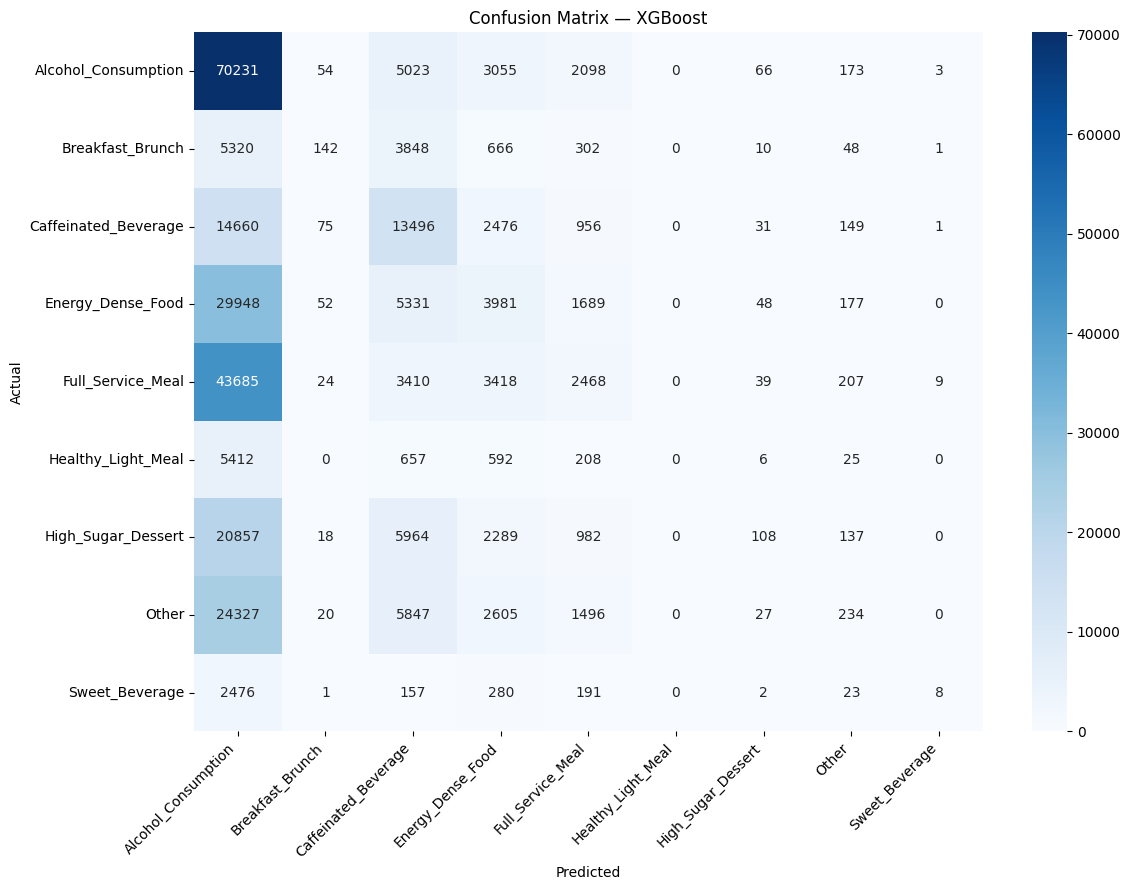

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix — XGBoost
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(12, 9))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=le.classes_, yticklabels=le.classes_,
    cmap="Blues"
)
plt.title("Confusion Matrix — XGBoost")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
# plt.savefig("./confusion_matrix_xgb.png", dpi=150)
plt.show()


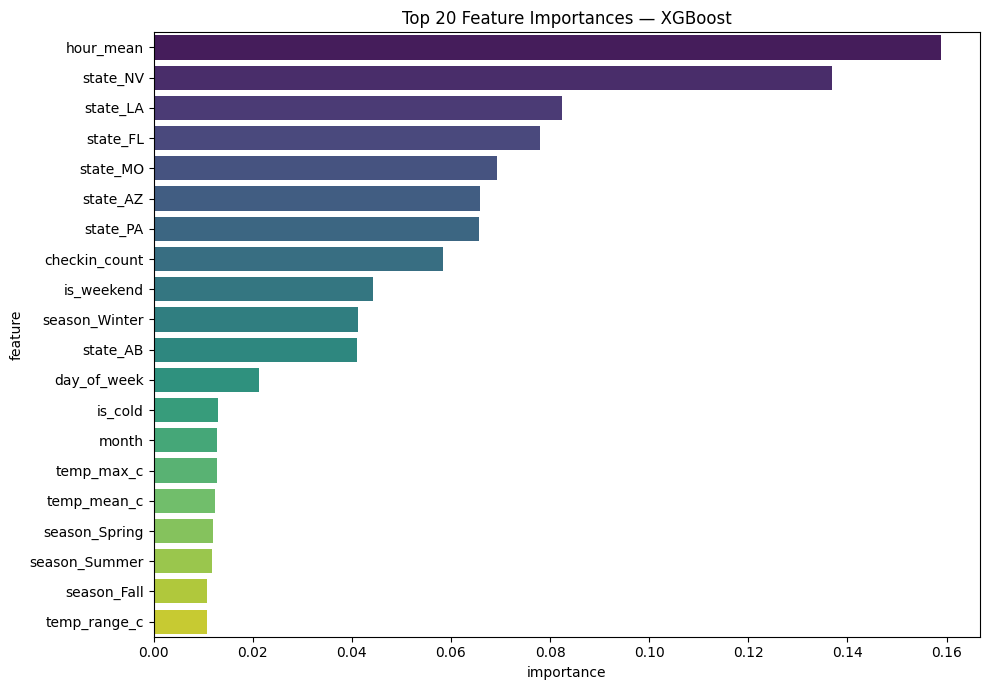

In [46]:
# Feature importance — XGBoost
importances = xgb_model.feature_importances_
feat_df = (
    pd.DataFrame({"feature": feature_cols_enc, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 7))
sns.barplot(data=feat_df, y="feature", x="importance", palette="viridis")
plt.title("Top 20 Feature Importances — XGBoost")
plt.tight_layout()
# plt.savefig("./feature_importances.png", dpi=150)
plt.show()



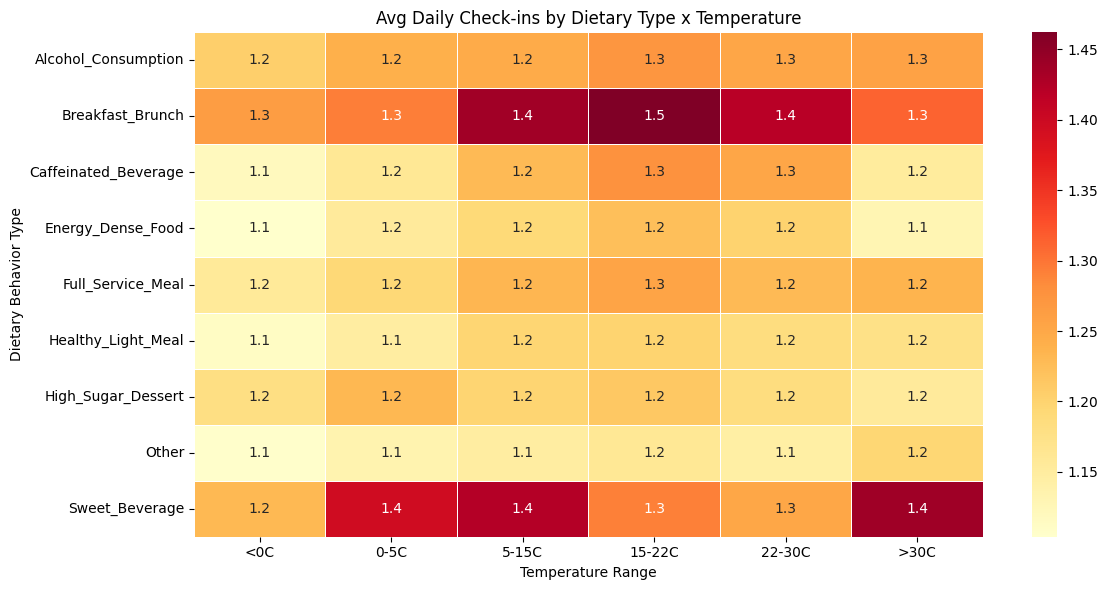

In [47]:
# Weather vs craving heatmap — avg check-ins per (dietary type × temp bucket)
agg["temp_bucket"] = pd.cut(
    agg["temp_mean_c"],
    bins=[-30, 0, 5, 15, 22, 30, 50],
    labels=["<0C", "0-5C", "5-15C", "15-22C", "22-30C", ">30C"]
)

pivot = (
    agg
    .groupby(["dietary_behavior_type", "temp_bucket"])["checkin_count"]
    .mean()
    .unstack("temp_bucket")
    .fillna(0)
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5)
plt.title("Avg Daily Check-ins by Dietary Type x Temperature")
plt.ylabel("Dietary Behavior Type")
plt.xlabel("Temperature Range")
plt.tight_layout()
# plt.savefig("./craving_weather_heatmap.png", dpi=150)
plt.show()


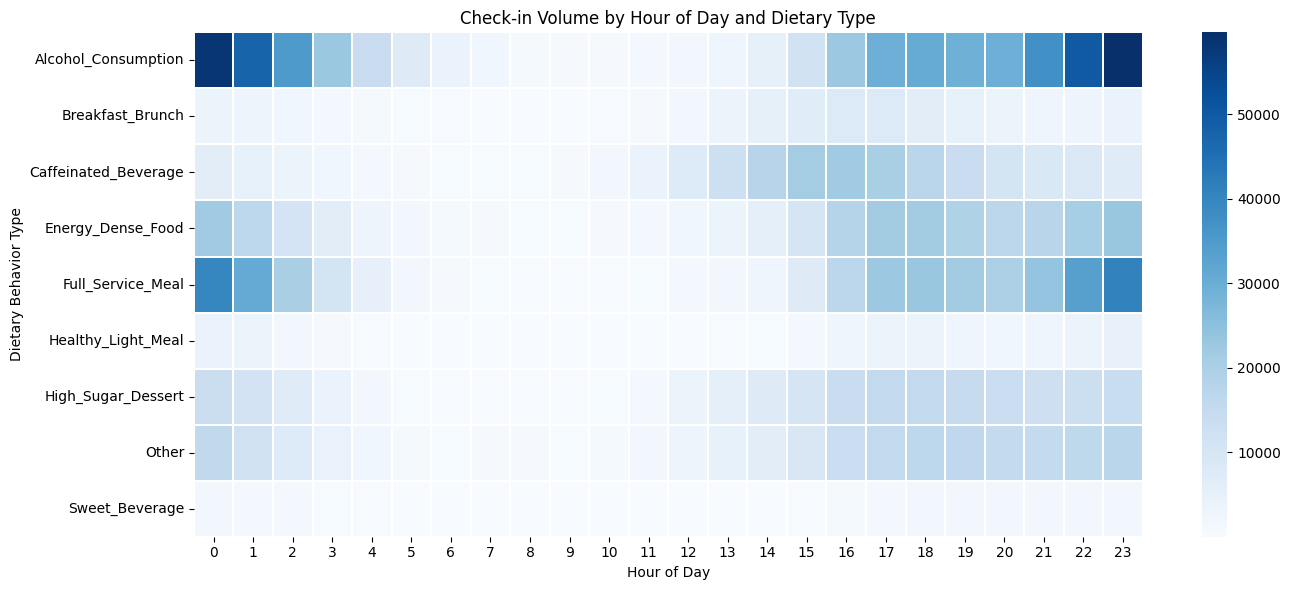

In [48]:
# Check-in volume by hour and dietary type
hour_pivot = (
    master
    .groupby(["dietary_behavior_type", "hour"])["business_id"]
    .count()
    .unstack("hour")
    .fillna(0)
)

plt.figure(figsize=(14, 6))
sns.heatmap(hour_pivot, cmap="Blues", linewidths=0.3)
plt.title("Check-in Volume by Hour of Day and Dietary Type")
plt.xlabel("Hour of Day")
plt.ylabel("Dietary Behavior Type")
plt.tight_layout()
# plt.savefig("./checkin_by_hour.png", dpi=150)
plt.show()


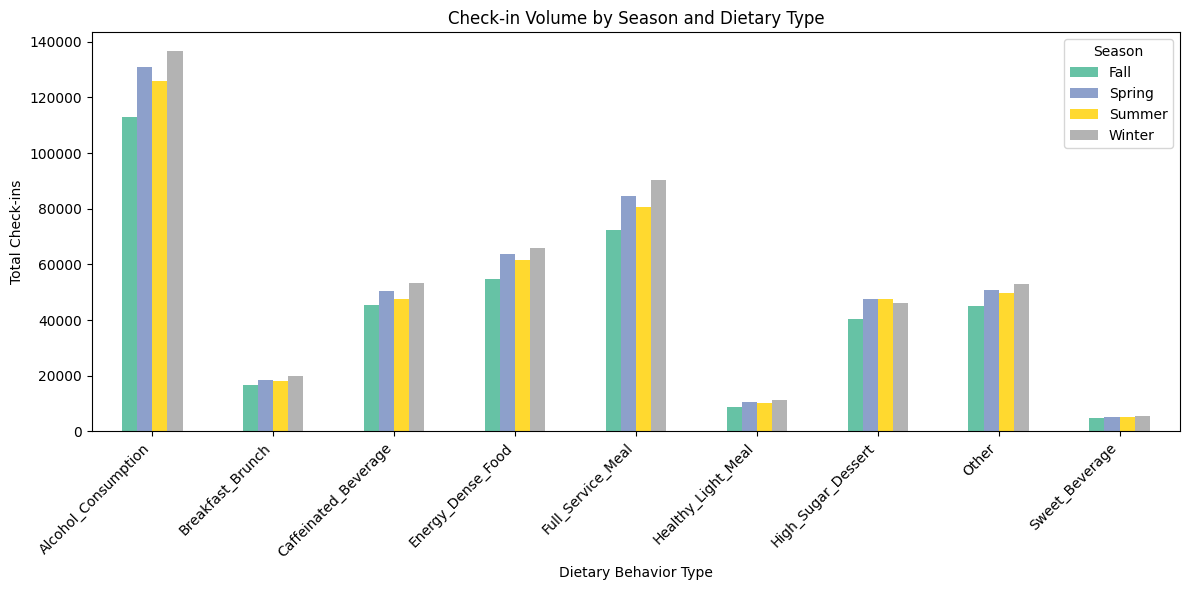

In [49]:
# Check-ins by season and dietary type
season_pivot = (
    master
    .groupby(["dietary_behavior_type", "season"])["business_id"]
    .count()
    .unstack("season")
    .fillna(0)
)

season_pivot.plot(kind="bar", figsize=(12, 6), colormap="Set2")
plt.title("Check-in Volume by Season and Dietary Type")
plt.xlabel("Dietary Behavior Type")
plt.ylabel("Total Check-ins")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Season")
plt.tight_layout()
# plt.savefig("./checkin_by_season.png", dpi=150)
plt.show()


---
## Step 8 — Predict Craving Given Any Weather Conditions

In [50]:
def predict_craving(
    temp_c: float,
    precip_mm: float,
    wind_kph: float,
    hour: int,
    day_of_week: int,    # 0=Mon ... 6=Sun
    month: int,
    state: str = "PA",
    stars: float = 3.5,
    review_count: int = 100,
    model=xgb_model,
) -> pd.DataFrame:
    """
    Predict top food craving probabilities given weather + time context.
    
    Example:
        predict_craving(temp_c=2, precip_mm=8, wind_kph=20,
                        hour=18, day_of_week=6, month=1, state="PA")
    """
    season_map = {
        12:"Winter",1:"Winter",2:"Winter",
        3:"Spring",4:"Spring",5:"Spring",
        6:"Summer",7:"Summer",8:"Summer",
        9:"Fall",10:"Fall",11:"Fall"
    }
    season = season_map[month]

    row = {
        "temp_mean_c":   temp_c,
        "temp_max_c":    temp_c + 3,
        "temp_range_c":  5.0,
        "precip_mm":     precip_mm,
        "wind_max_kph":  wind_kph,
        "is_rainy":      int(precip_mm > 1),
        "is_cold":       int(temp_c < 5),
        "is_hot":        int(temp_c > 28),
        "hour_mean":     hour,
        "is_weekend":    int(day_of_week >= 5),
        "month":         month,
        "day_of_week":   day_of_week,
        "checkin_count": 1,
    }

    # One-hot season and state
    for s in ["Fall","Spring","Summer","Winter"]:
        row[f"season_{s}"] = int(season == s)
    for st in STATE_COORDS.keys():
        row[f"state_{st}"] = int(state == st)

    df_row = pd.DataFrame([row])
    for col in feature_cols_enc:
        if col not in df_row.columns:
            df_row[col] = 0
    df_row = df_row[feature_cols_enc].fillna(0)

    proba = model.predict_proba(df_row)[0]
    result = (
        pd.DataFrame({"craving": le.classes_, "probability": proba})
        .sort_values("probability", ascending=False)
        .reset_index(drop=True)
    )
    result["probability"] = result["probability"].round(4)
    return result


In [51]:
# Example 1: Cold rainy winter Sunday evening in Philadelphia
print("--- Cold rainy winter Sunday, 6pm, Philadelphia ---")
display(predict_craving(
    temp_c=2, precip_mm=8, wind_kph=25,
    hour=18, day_of_week=6, month=1, state="PA"
))

# Example 2: Hot dry summer Saturday afternoon in Las Vegas
print("\n--- Hot dry summer Saturday, 2pm, Las Vegas ---")
display(predict_craving(
    temp_c=38, precip_mm=0, wind_kph=10,
    hour=14, day_of_week=5, month=7, state="NV"
))

# Example 3: Mild spring weekday morning in Chicago
print("\n--- Mild spring Tuesday, 9am, Chicago ---")
display(predict_craving(
    temp_c=15, precip_mm=0, wind_kph=12,
    hour=9, day_of_week=1, month=4, state="IL"
))


--- Cold rainy winter Sunday, 6pm, Philadelphia ---


,craving,probability
0,Alcohol_Consumption,0.2028
1,Full_Service_Meal,0.1708
2,Energy_Dense_Food,0.1580
3,Caffeinated_Beverage,0.1375
4,High_Sugar_Dessert,0.1251
5,Other,0.1241
6,Breakfast_Brunch,0.0358
7,Healthy_Light_Meal,0.0265
8,Sweet_Beverage,0.0194



--- Hot dry summer Saturday, 2pm, Las Vegas ---


,craving,probability
0,Caffeinated_Beverage,0.3903
1,Other,0.1670
2,High_Sugar_Dessert,0.1065
3,Alcohol_Consumption,0.0979
4,Breakfast_Brunch,0.0933
5,Energy_Dense_Food,0.0765
6,Full_Service_Meal,0.0558
7,Healthy_Light_Meal,0.0077
8,Sweet_Beverage,0.0051



--- Mild spring Tuesday, 9am, Chicago ---


,craving,probability
0,Caffeinated_Beverage,0.2246
1,Other,0.1714
2,Alcohol_Consumption,0.1707
3,Energy_Dense_Food,0.1573
4,High_Sugar_Dessert,0.1041
5,Full_Service_Meal,0.1007
6,Breakfast_Brunch,0.0509
7,Healthy_Light_Meal,0.0146
8,Sweet_Beverage,0.0058


In [52]:
import plotly.graph_objects as go

scenarios = {
    "Philadelphia\n(cold, rainy)": predict_craving(temp_c=2, precip_mm=8, wind_kph=25, hour=18, day_of_week=6, month=1, state="PA"),
    "Las Vegas\n(hot, dry)":       predict_craving(temp_c=38, precip_mm=0, wind_kph=10, hour=14, day_of_week=5, month=7, state="NV"),
    "Chicago\n(mild, clear)":      predict_craving(temp_c=15, precip_mm=0, wind_kph=12, hour=9, day_of_week=1, month=4, state="IL"),
}

fig = go.Figure()
colors = ["#378ADD", "#D85A30", "#639922"]

for (name, df), color in zip(scenarios.items(), colors):
    top5 = df.head(5)
    fig.add_trace(go.Bar(
        name=name, x=top5["craving"], y=(top5["probability"]*100).round(1),
        marker_color=color, text=(top5["probability"]*100).round(1).astype(str)+"%",
        textposition="outside"
    ))

fig.update_layout(
    barmode="group", title="Food craving predictions by weather scenario",
    yaxis_title="Probability (%)", xaxis_title="Dietary behavior type",
    legend_title="Scenario", plot_bgcolor="white", height=500
)
fig.show()